# Final Preprocessing Decision

This notebook explains the last preprocessing choice: which scaler to use for the compact business feature set. It is evidence only and does not write output files.


## Decision Logic

1. Keep the compact 20-feature business set from `06c`.
2. Compare StandardScaler, RobustScaler, and simple log variants with K-Means `k=5`.
3. Confirm the scaler used by the official preprocessing pipeline.


## Imports


In [6]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import RobustScaler, StandardScaler

sys.path.append("../src")

from clustering import compare_kmeans_feature_sets
from preprocessing import FINAL_MODEL_COLUMNS, clean_feature_values, scale_model_features


## Load Customer Features


In [7]:
customer_features = pd.read_csv("../data/processed/customer_features_info.csv")
clean_customer_features = clean_feature_values(customer_features)

pd.DataFrame({
    "check": ["rows", "unique customer_id", "compact feature count"],
    "value": [
        len(clean_customer_features),
        clean_customer_features["customer_id"].nunique(),
        len(FINAL_MODEL_COLUMNS),
    ],
})


,check,value
0,rows,33038
1,unique customer_id,33038
2,compact feature count,20


## Build Scaler Candidates


In [8]:
scaler_feature_sets = {
    "compact_standard_scaler": scale_model_features(
        clean_customer_features,
        scaler=StandardScaler(),
    ),
    "compact_robust_scaler": scale_model_features(
        clean_customer_features,
        scaler=RobustScaler(),
    ),
    "compact_log_standard_scaler": scale_model_features(
        clean_customer_features,
        scaler=StandardScaler(),
        use_log=True,
    ),
    "compact_log_robust_scaler": scale_model_features(
        clean_customer_features,
        scaler=RobustScaler(),
        use_log=True,
    ),
}

pd.DataFrame(
    {"candidate": name, "feature_count": features.shape[1]}
    for name, features in scaler_feature_sets.items()
)


,candidate,feature_count
0,compact_standard_scaler,20
1,compact_robust_scaler,20
2,compact_log_standard_scaler,20
3,compact_log_robust_scaler,20


## Compare Scalers With k=5


In [9]:
scaler_metrics = compare_kmeans_feature_sets(
    scaler_feature_sets,
    k=5,
    random_state=42,
    n_init=50,
    sample_size=10000,
)

scaler_metrics = scaler_metrics[[
    "feature_set_variant",
    "k",
    "random_state",
    "n_features",
    "inertia",
    "silhouette_score",
    "calinski_harabasz_score",
    "davies_bouldin_score",
    "min_cluster_size",
    "max_cluster_size",
    "min_cluster_percentage",
    "max_cluster_percentage",
]].sort_values("silhouette_score", ascending=False)

scaler_metrics


,feature_set_variant,k,random_state,n_features,inertia,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage
1,compact_robust_scaler,5,42,20,391157.562262,0.220848,6347.157519,1.539205,2619,18385,7.927235,55.648042
2,compact_log_standard_scaler,5,42,20,448858.850744,0.144037,3898.626954,2.038362,2215,13115,6.704401,39.696713
0,compact_standard_scaler,5,42,20,450976.067804,0.141156,3841.553195,2.057096,2233,10769,6.758884,32.595799
3,compact_log_robust_scaler,5,42,20,361303.356386,0.138231,5646.035914,1.948451,2126,10877,6.435014,32.922695


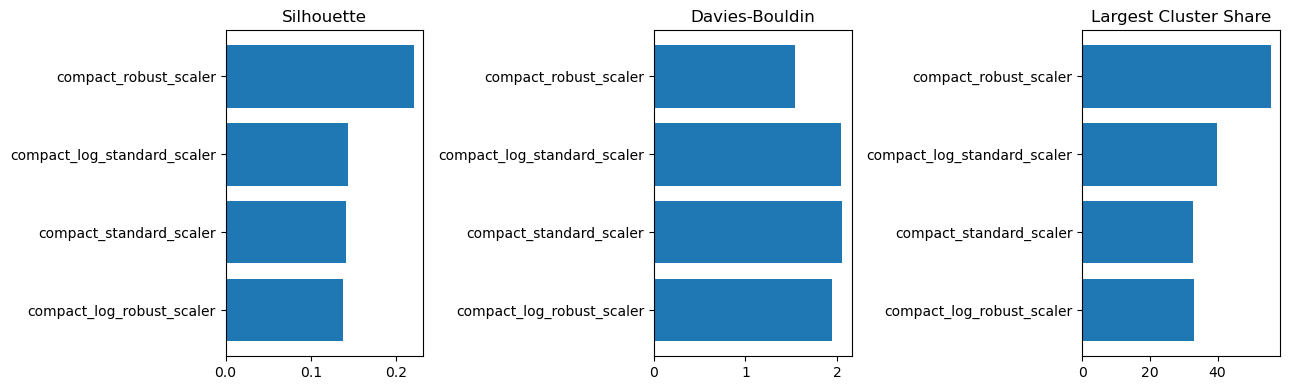

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].barh(scaler_metrics["feature_set_variant"], scaler_metrics["silhouette_score"])
axes[0].set_title("Silhouette")
axes[0].invert_yaxis()

axes[1].barh(scaler_metrics["feature_set_variant"], scaler_metrics["davies_bouldin_score"])
axes[1].set_title("Davies-Bouldin")
axes[1].invert_yaxis()

axes[2].barh(scaler_metrics["feature_set_variant"], scaler_metrics["max_cluster_percentage"])
axes[2].set_title("Largest Cluster Share")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


## Conclusion

`compact_robust_scaler` is the final preprocessing choice. It gives the strongest overall internal metrics among the compact feature variants while keeping the final model simple and reproducible. The official preprocessing notebook now produces this exact input, and the final K-Means output is regenerated from it.
